# GovReport Full Dataset Analysis

Complete analysis of the full GovReport dataset (train + validation splits).

**Data Source:**
- Dataset: GovReport (HuggingFace: ccdv/govreport-summarization)
- Train split: 17,517 samples
- Validation split: 973 samples
- Total: 18,490 samples

**Analysis includes:**
1. Character length distribution
2. Word count distribution
3. Token length distribution (using Qwen tokenizer)
4. Context length categories (8K/16K/32K)
5. Compression ratios
6. Statistical summaries

In [11]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from datasets import load_dataset
from tqdm import tqdm

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Full Dataset

In [12]:
# Load GovReport dataset from HuggingFace
print("Loading GovReport dataset from HuggingFace...")
govreport = load_dataset("ccdv/govreport-summarization", trust_remote_code=True)

train_data = govreport["train"]
val_data = govreport["validation"]

print(f"  Train split: {len(train_data):,} samples")
print(f"  Validation split: {len(val_data):,} samples")
print(f"  Total: {len(train_data) + len(val_data):,} samples")

# Extract documents and summaries
print("\nExtracting documents and summaries...")
all_docs = [sample["report"] for sample in train_data] + [sample["report"] for sample in val_data]
all_summaries = [sample["summary"] for sample in train_data] + [sample["summary"] for sample in val_data]

print(f"  Extracted {len(all_docs):,} documents")
print(f"  Extracted {len(all_summaries):,} summaries")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/govreport-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading GovReport dataset from HuggingFace...
  Train split: 17,517 samples
  Validation split: 973 samples
  Total: 18,490 samples

Extracting documents and summaries...
  Extracted 18,490 documents
  Extracted 18,490 summaries


## 2. Character Length Analysis

In [13]:
# Calculate character lengths
doc_chars = [len(d) for d in all_docs]
summary_chars = [len(s) for s in all_summaries]

print("=" * 80)
print("CHARACTER LENGTH STATISTICS")
print("=" * 80)

print("\nDocuments:")
print(f"  Total samples: {len(doc_chars):,}")
print(f"  Min:    {min(doc_chars):,} chars")
print(f"  Max:    {max(doc_chars):,} chars")
print(f"  Mean:   {np.mean(doc_chars):,.0f} chars")
print(f"  Median: {np.median(doc_chars):,.0f} chars")
print(f"  Std:    {np.std(doc_chars):,.0f} chars")
print(f"  P25:    {np.percentile(doc_chars, 25):,.0f} chars")
print(f"  P75:    {np.percentile(doc_chars, 75):,.0f} chars")
print(f"  P90:    {np.percentile(doc_chars, 90):,.0f} chars")
print(f"  P95:    {np.percentile(doc_chars, 95):,.0f} chars")
print(f"  P99:    {np.percentile(doc_chars, 99):,.0f} chars")

print("\nSummaries:")
print(f"  Total samples: {len(summary_chars):,}")
print(f"  Min:    {min(summary_chars):,} chars")
print(f"  Max:    {max(summary_chars):,} chars")
print(f"  Mean:   {np.mean(summary_chars):,.0f} chars")
print(f"  Median: {np.median(summary_chars):,.0f} chars")
print(f"  Std:    {np.std(summary_chars):,.0f} chars")
print(f"  P25:    {np.percentile(summary_chars, 25):,.0f} chars")
print(f"  P75:    {np.percentile(summary_chars, 75):,.0f} chars")
print(f"  P90:    {np.percentile(summary_chars, 90):,.0f} chars")
print(f"  P95:    {np.percentile(summary_chars, 95):,.0f} chars")
print(f"  P99:    {np.percentile(summary_chars, 99):,.0f} chars")

char_compression_ratios = [d/s if s > 0 else 0 for d, s in zip(doc_chars, summary_chars)]
print("\nCompression Ratio (chars):")
print(f"  Mean:   {np.mean(char_compression_ratios):.1f}x")
print(f"  Median: {np.median(char_compression_ratios):.1f}x")

CHARACTER LENGTH STATISTICS

Documents:
  Total samples: 18,490
  Min:    320 chars
  Max:    1,323,870 chars
  Mean:   51,194 chars
  Median: 42,768 chars
  Std:    39,525 chars
  P25:    26,475 chars
  P75:    64,675 chars
  P90:    91,841 chars
  P95:    114,982 chars
  P99:    188,084 chars

Summaries:
  Total samples: 18,490
  Min:    127 chars
  Max:    13,652 chars
  Mean:   3,235 chars
  Median: 3,306 chars
  Std:    1,152 chars
  P25:    2,571 chars
  P75:    4,026 chars
  P90:    4,670 chars
  P95:    4,927 chars
  P99:    5,345 chars

Compression Ratio (chars):
  Mean:   17.9x
  Median: 13.8x


## 3. Word Count Analysis

In [14]:
# Count words
def count_words(text):
    return len(text.split())

print("Counting words in all samples...")
doc_words = [count_words(d) for d in tqdm(all_docs, desc="Documents")]
summary_words = [count_words(s) for s in tqdm(all_summaries, desc="Summaries")]

print("\n" + "=" * 80)
print("WORD COUNT STATISTICS")
print("=" * 80)

print("\nDocuments:")
print(f"  Total samples: {len(doc_words):,}")
print(f"  Min:    {min(doc_words):,} words")
print(f"  Max:    {max(doc_words):,} words")
print(f"  Mean:   {np.mean(doc_words):,.0f} words")
print(f"  Median: {np.median(doc_words):,.0f} words")
print(f"  Std:    {np.std(doc_words):,.0f} words")
print(f"  P25:    {np.percentile(doc_words, 25):,.0f} words")
print(f"  P75:    {np.percentile(doc_words, 75):,.0f} words")
print(f"  P90:    {np.percentile(doc_words, 90):,.0f} words")
print(f"  P95:    {np.percentile(doc_words, 95):,.0f} words")
print(f"  P99:    {np.percentile(doc_words, 99):,.0f} words")

print("\nSummaries:")
print(f"  Total samples: {len(summary_words):,}")
print(f"  Min:    {min(summary_words):,} words")
print(f"  Max:    {max(summary_words):,} words")
print(f"  Mean:   {np.mean(summary_words):,.0f} words")
print(f"  Median: {np.median(summary_words):,.0f} words")
print(f"  Std:    {np.std(summary_words):,.0f} words")
print(f"  P25:    {np.percentile(summary_words, 25):,.0f} words")
print(f"  P75:    {np.percentile(summary_words, 75):,.0f} words")
print(f"  P90:    {np.percentile(summary_words, 90):,.0f} words")
print(f"  P95:    {np.percentile(summary_words, 95):,.0f} words")
print(f"  P99:    {np.percentile(summary_words, 99):,.0f} words")

word_compression_ratios = [d/s if s > 0 else 0 for d, s in zip(doc_words, summary_words)]
print("\nCompression Ratio (words):")
print(f"  Mean:   {np.mean(word_compression_ratios):.1f}x")
print(f"  Median: {np.median(word_compression_ratios):.1f}x")

Counting words in all samples...


Summaries: 100%|████████████████████████████████████████████████████████████████████████████████████████| 18490/18490 [00:00<00:00, 93926.97it/s]



WORD COUNT STATISTICS

Documents:
  Total samples: 18,490
  Min:    55 words
  Max:    215,932 words
  Mean:   7,750 words
  Median: 6,480 words
  Std:    5,999 words
  P25:    4,020 words
  P75:    9,795 words
  P90:    13,906 words
  P95:    17,400 words
  P99:    28,315 words

Summaries:
  Total samples: 18,490
  Min:    20 words
  Max:    1,890 words
  Mean:   483 words
  Median: 496 words
  Std:    172 words
  P25:    383 words
  P75:    602 words
  P90:    691 words
  P95:    733 words
  P99:    814 words

Compression Ratio (words):
  Mean:   18.3x
  Median: 14.0x


## 4. Token Length Analysis (Qwen Tokenizer)

In [15]:
# Load Qwen3 tokenizer for accurate token counting
from transformers import AutoTokenizer

print("Loading Qwen3-0.6B tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("unsloth/Qwen3-0.6B")
print("✓ Tokenizer loaded")

# Tokenize all documents and summaries
print("\nTokenizing all samples (this may take 3-5 minutes)...")
doc_tokens = []
for doc in tqdm(all_docs, desc="Tokenizing documents"):
    tokens = tokenizer(doc, truncation=False, add_special_tokens=False)['input_ids']
    doc_tokens.append(len(tokens))

summary_tokens = []
for summary in tqdm(all_summaries, desc="Tokenizing summaries"):
    tokens = tokenizer(summary, truncation=False, add_special_tokens=False)['input_ids']
    summary_tokens.append(len(tokens))

total_tokens = [d + s for d, s in zip(doc_tokens, summary_tokens)]
print("✓ Tokenization complete")

print("\n" + "=" * 80)
print("TOKEN LENGTH STATISTICS (Qwen3-0.6B Tokenizer)")
print("=" * 80)

print("\nDocument tokens:")
print(f"  Min:    {min(doc_tokens):,} tokens")
print(f"  Max:    {max(doc_tokens):,} tokens")
print(f"  Mean:   {np.mean(doc_tokens):,.0f} tokens")
print(f"  Median: {np.median(doc_tokens):,.0f} tokens")
print(f"  Std:    {np.std(doc_tokens):,.0f} tokens")
print(f"  P25:    {np.percentile(doc_tokens, 25):,.0f} tokens")
print(f"  P75:    {np.percentile(doc_tokens, 75):,.0f} tokens")
print(f"  P90:    {np.percentile(doc_tokens, 90):,.0f} tokens")
print(f"  P95:    {np.percentile(doc_tokens, 95):,.0f} tokens")
print(f"  P99:    {np.percentile(doc_tokens, 99):,.0f} tokens")

print("\nSummary tokens:")
print(f"  Min:    {min(summary_tokens):,} tokens")
print(f"  Max:    {max(summary_tokens):,} tokens")
print(f"  Mean:   {np.mean(summary_tokens):,.0f} tokens")
print(f"  Median: {np.median(summary_tokens):,.0f} tokens")
print(f"  Std:    {np.std(summary_tokens):,.0f} tokens")

print("\nTotal tokens (document + summary):")
print(f"  Min:    {min(total_tokens):,} tokens")
print(f"  Max:    {max(total_tokens):,} tokens")
print(f"  Mean:   {np.mean(total_tokens):,.0f} tokens")
print(f"  Median: {np.median(total_tokens):,.0f} tokens")
print(f"  Std:    {np.std(total_tokens):,.0f} tokens")

Loading Qwen3-0.6B tokenizer...
✓ Tokenizer loaded

Tokenizing all samples (this may take 3-5 minutes)...


Tokenizing summaries: 100%|██████████████████████████████████████████████████████████████████████████████| 18490/18490 [00:11<00:00, 1630.78it/s]

✓ Tokenization complete

TOKEN LENGTH STATISTICS (Qwen3-0.6B Tokenizer)

Document tokens:
  Min:    77 tokens
  Max:    338,822 tokens
  Mean:   9,988 tokens
  Median: 8,294 tokens
  Std:    8,002 tokens
  P25:    5,185 tokens
  P75:    12,495 tokens
  P90:    17,675 tokens
  P95:    22,367 tokens
  P99:    38,910 tokens

Summary tokens:
  Min:    23 tokens
  Max:    2,388 tokens
  Mean:   628 tokens
  Median: 648 tokens
  Std:    225 tokens

Total tokens (document + summary):
  Min:    311 tokens
  Max:    338,888 tokens
  Mean:   10,616 tokens
  Median: 8,948 tokens
  Std:    8,045 tokens


## 5. Context Length Distribution (8K/16K/32K)

In [16]:
# Categorize by context length
def categorize_length(tokens):
    if tokens <= 8192:
        return '8K'
    elif tokens <= 16384:
        return '16K'
    elif tokens <= 32768:
        return '32K'
    else:
        return '>32K'

categories = [categorize_length(t) for t in total_tokens]
category_counts = Counter(categories)

print("=" * 80)
print("CONTEXT LENGTH DISTRIBUTION")
print("=" * 80)
print(f"\n8K (≤8,192 tokens):    {category_counts.get('8K', 0):5d} samples ({category_counts.get('8K', 0)/len(total_tokens)*100:.1f}%)")
print(f"16K (8K-16K tokens):   {category_counts.get('16K', 0):5d} samples ({category_counts.get('16K', 0)/len(total_tokens)*100:.1f}%)")
print(f"32K (16K-32K tokens):  {category_counts.get('32K', 0):5d} samples ({category_counts.get('32K', 0)/len(total_tokens)*100:.1f}%)")
print(f">32K (>32K tokens):    {category_counts.get('>32K', 0):5d} samples ({category_counts.get('>32K', 0)/len(total_tokens)*100:.1f}%)")
print(f"\nTotal: {len(total_tokens):,} samples")

print("\nCumulative Coverage:")
print(f"  ≤8K:  {category_counts.get('8K', 0)/len(total_tokens)*100:.1f}%")
print(f"  ≤16K: {(category_counts.get('8K', 0) + category_counts.get('16K', 0))/len(total_tokens)*100:.1f}%")
print(f"  ≤32K: {(category_counts.get('8K', 0) + category_counts.get('16K', 0) + category_counts.get('32K', 0))/len(total_tokens)*100:.1f}%")

CONTEXT LENGTH DISTRIBUTION

8K (≤8,192 tokens):     8215 samples (44.4%)
16K (8K-16K tokens):    7677 samples (41.5%)
32K (16K-32K tokens):   2278 samples (12.3%)
>32K (>32K tokens):      320 samples (1.7%)

Total: 18,490 samples

Cumulative Coverage:
  ≤8K:  44.4%
  ≤16K: 85.9%
  ≤32K: 98.3%


## 6. Visualizations

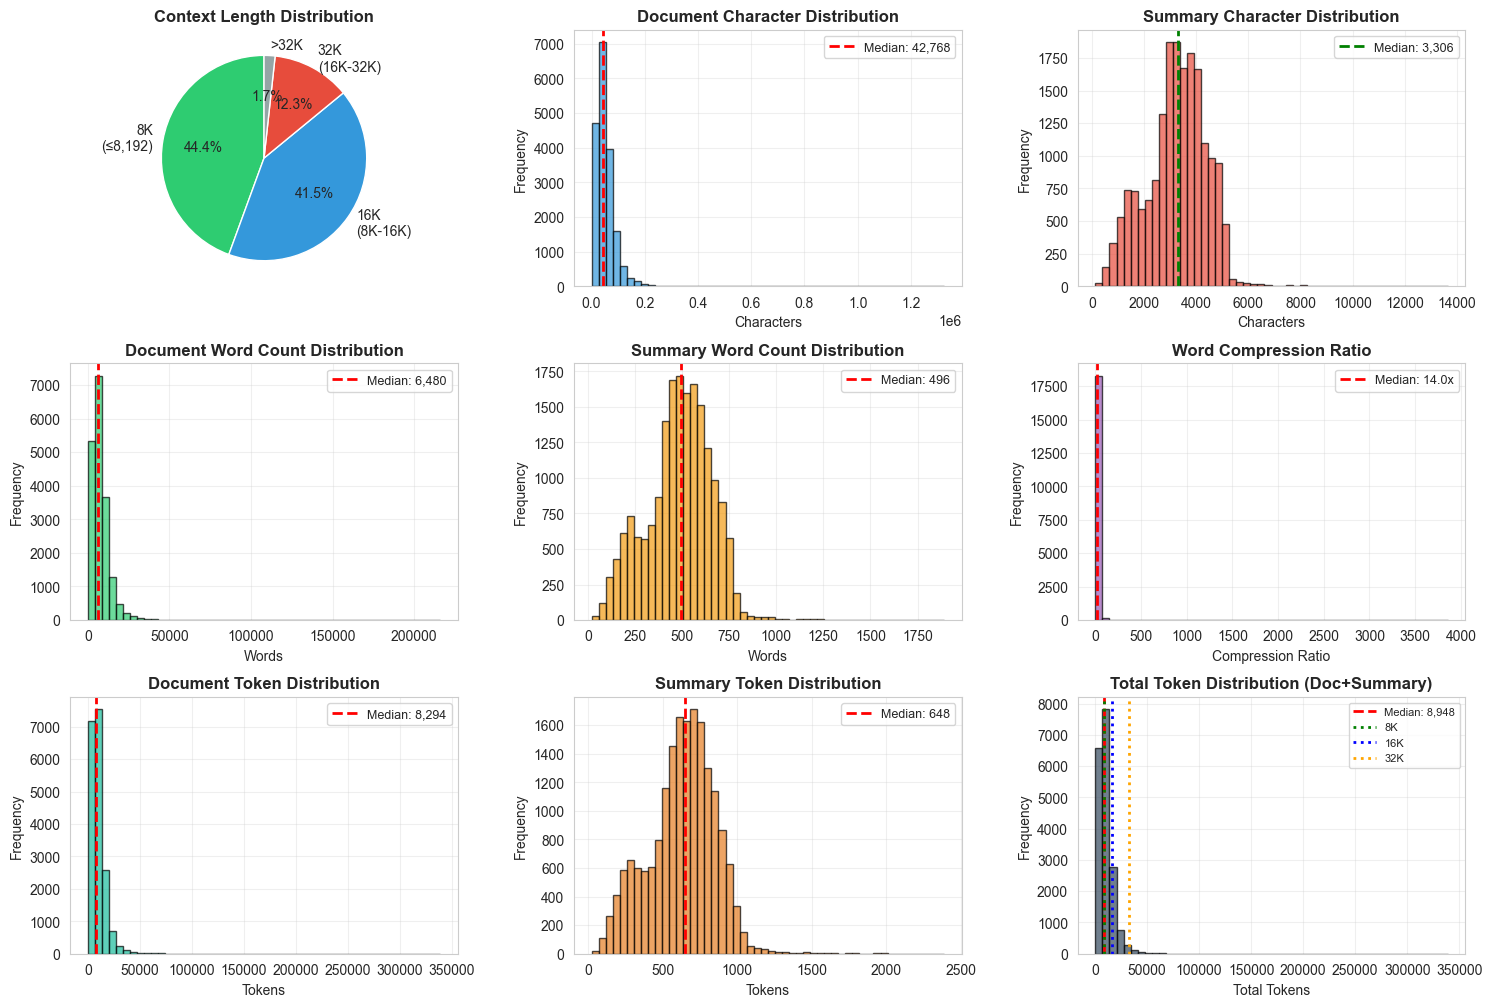


✓ Saved visualization: full_dataset_distribution.png


In [17]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Context length distribution (pie chart)
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
pie_data = [
    category_counts.get('8K', 0),
    category_counts.get('16K', 0),
    category_counts.get('32K', 0),
    category_counts.get('>32K', 0)
]
pie_labels = ['8K\n(≤8,192)', '16K\n(8K-16K)', '32K\n(16K-32K)', '>32K']
ax1.pie(
    pie_data,
    labels=pie_labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10}
)
ax1.set_title('Context Length Distribution', fontsize=12, fontweight='bold')

# 2. Document character distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(doc_chars, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
ax2.axvline(np.median(doc_chars), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_chars):,.0f}')
ax2.set_xlabel('Characters', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Document Character Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Summary character distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(summary_chars, bins=50, alpha=0.7, color='#e74c3c', edgecolor='black')
ax3.axvline(np.median(summary_chars), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(summary_chars):,.0f}')
ax3.set_xlabel('Characters', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Summary Character Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Document word count distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(doc_words, bins=50, alpha=0.7, color='#2ecc71', edgecolor='black')
ax4.axvline(np.median(doc_words), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_words):,.0f}')
ax4.set_xlabel('Words', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.set_title('Document Word Count Distribution', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Summary word count distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(summary_words, bins=50, alpha=0.7, color='#f39c12', edgecolor='black')
ax5.axvline(np.median(summary_words), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(summary_words):,.0f}')
ax5.set_xlabel('Words', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.set_title('Summary Word Count Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Word compression ratio
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(word_compression_ratios, bins=50, alpha=0.7, color='#9b59b6', edgecolor='black')
ax6.axvline(np.median(word_compression_ratios), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(word_compression_ratios):.1f}x')
ax6.set_xlabel('Compression Ratio', fontsize=10)
ax6.set_ylabel('Frequency', fontsize=10)
ax6.set_title('Word Compression Ratio', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

# 7. Document token distribution
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(doc_tokens, bins=50, alpha=0.7, color='#1abc9c', edgecolor='black')
ax7.axvline(np.median(doc_tokens), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(doc_tokens):,.0f}')
ax7.set_xlabel('Tokens', fontsize=10)
ax7.set_ylabel('Frequency', fontsize=10)
ax7.set_title('Document Token Distribution', fontsize=12, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3)

# 8. Summary token distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(summary_tokens, bins=50, alpha=0.7, color='#e67e22', edgecolor='black')
ax8.axvline(np.median(summary_tokens), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(summary_tokens):,.0f}')
ax8.set_xlabel('Tokens', fontsize=10)
ax8.set_ylabel('Frequency', fontsize=10)
ax8.set_title('Summary Token Distribution', fontsize=12, fontweight='bold')
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.3)

# 9. Total token distribution
ax9 = fig.add_subplot(gs[2, 2])
ax9.hist(total_tokens, bins=50, alpha=0.7, color='#34495e', edgecolor='black')
ax9.axvline(np.median(total_tokens), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(total_tokens):,.0f}')
ax9.axvline(8192, color='green', linestyle=':', linewidth=2, label='8K')
ax9.axvline(16384, color='blue', linestyle=':', linewidth=2, label='16K')
ax9.axvline(32768, color='orange', linestyle=':', linewidth=2, label='32K')
ax9.set_xlabel('Total Tokens', fontsize=10)
ax9.set_ylabel('Frequency', fontsize=10)
ax9.set_title('Total Token Distribution (Doc+Summary)', fontsize=12, fontweight='bold')
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3)

plt.savefig('full_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: full_dataset_distribution.png")

## 7. Percentile Analysis

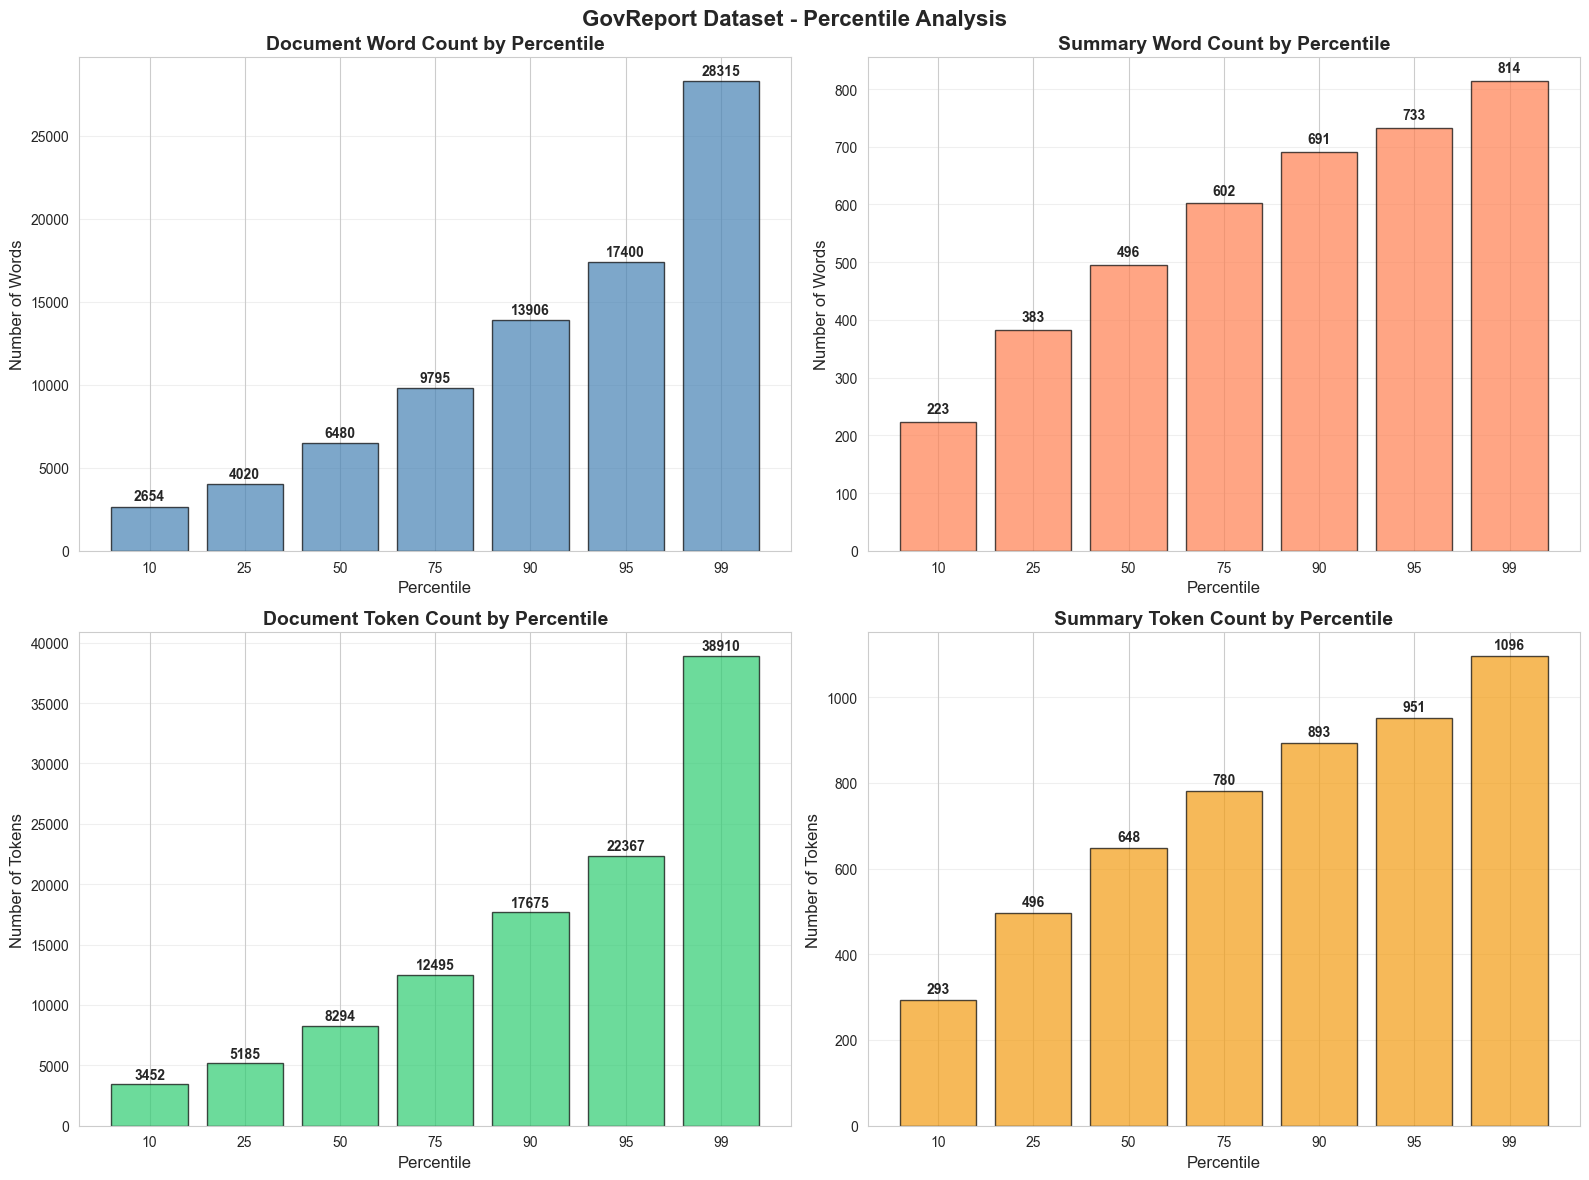


✓ Saved plot: percentile_analysis.png


In [18]:
# Create percentile comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GovReport Dataset - Percentile Analysis', fontsize=16, fontweight='bold')

percentiles = [10, 25, 50, 75, 90, 95, 99]

# Document words percentiles
ax = axes[0, 0]
doc_word_p = [np.percentile(doc_words, p) for p in percentiles]
ax.bar([str(p) for p in percentiles], doc_word_p, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.set_title('Document Word Count by Percentile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(doc_word_p):
    ax.text(i, v + 200, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Summary words percentiles
ax = axes[0, 1]
sum_word_p = [np.percentile(summary_words, p) for p in percentiles]
ax.bar([str(p) for p in percentiles], sum_word_p, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.set_title('Summary Word Count by Percentile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sum_word_p):
    ax.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Document tokens percentiles
ax = axes[1, 0]
doc_token_p = [np.percentile(doc_tokens, p) for p in percentiles]
ax.bar([str(p) for p in percentiles], doc_token_p, color='#2ecc71', alpha=0.7, edgecolor='black')
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Number of Tokens', fontsize=12)
ax.set_title('Document Token Count by Percentile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(doc_token_p):
    ax.text(i, v + 200, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Summary tokens percentiles
ax = axes[1, 1]
sum_token_p = [np.percentile(summary_tokens, p) for p in percentiles]
ax.bar([str(p) for p in percentiles], sum_token_p, color='#f39c12', alpha=0.7, edgecolor='black')
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Number of Tokens', fontsize=12)
ax.set_title('Summary Token Count by Percentile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sum_token_p):
    ax.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('percentile_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved plot: percentile_analysis.png")

## 8. Summary Statistics

In [19]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"  Total samples: {len(all_docs):,}")
print(f"  Train split: {len(train_data):,}")
print(f"  Validation split: {len(val_data):,}")

print(f"\n📏 Context Distribution:")
print(f"  8K:  {category_counts.get('8K', 0):5d} ({category_counts.get('8K', 0)/len(total_tokens)*100:.1f}%)")
print(f"  16K: {category_counts.get('16K', 0):5d} ({category_counts.get('16K', 0)/len(total_tokens)*100:.1f}%)")
print(f"  32K: {category_counts.get('32K', 0):5d} ({category_counts.get('32K', 0)/len(total_tokens)*100:.1f}%)")
print(f"  >32K: {category_counts.get('>32K', 0):4d} ({category_counts.get('>32K', 0)/len(total_tokens)*100:.1f}%)")

print(f"\n📝 Length Statistics:")
print(f"  Documents:")
print(f"    Avg: {np.mean(doc_chars):,.0f} chars / {np.mean(doc_words):,.0f} words / {np.mean(doc_tokens):,.0f} tokens")
print(f"  Summaries:")
print(f"    Avg: {np.mean(summary_chars):,.0f} chars / {np.mean(summary_words):,.0f} words / {np.mean(summary_tokens):,.0f} tokens")

print(f"\n📊 Compression Ratios:")
print(f"  Characters: {np.mean(char_compression_ratios):.1f}x (median: {np.median(char_compression_ratios):.1f}x)")
print(f"  Words:      {np.mean(word_compression_ratios):.1f}x (median: {np.median(word_compression_ratios):.1f}x)")

print(f"\n💡 Key Insights:")
print(f"  • {(category_counts.get('8K', 0) + category_counts.get('16K', 0))/len(total_tokens)*100:.1f}% of data fits in ≤16K context")
print(f"  • {(category_counts.get('8K', 0) + category_counts.get('16K', 0) + category_counts.get('32K', 0))/len(total_tokens)*100:.1f}% of data fits in ≤32K context")
print(f"  • Use max_seq_length=32768 to cover {(category_counts.get('8K', 0) + category_counts.get('16K', 0) + category_counts.get('32K', 0))/len(total_tokens)*100:.1f}% of samples")
print(f"  • Average document: ~{np.mean(doc_words):.0f} words (~{np.mean(doc_tokens):.0f} tokens)")
print(f"  • Average summary: ~{np.mean(summary_words):.0f} words (~{np.mean(summary_tokens):.0f} tokens)")
print(f"  • Summaries are ~{np.mean(word_compression_ratios):.1f}x shorter than documents")

print("\n" + "=" * 80)

FINAL SUMMARY

📊 Dataset Overview:
  Total samples: 18,490
  Train split: 17,517
  Validation split: 973

📏 Context Distribution:
  8K:   8215 (44.4%)
  16K:  7677 (41.5%)
  32K:  2278 (12.3%)
  >32K:  320 (1.7%)

📝 Length Statistics:
  Documents:
    Avg: 51,194 chars / 7,750 words / 9,988 tokens
  Summaries:
    Avg: 3,235 chars / 483 words / 628 tokens

📊 Compression Ratios:
  Characters: 17.9x (median: 13.8x)
  Words:      18.3x (median: 14.0x)

💡 Key Insights:
  • 85.9% of data fits in ≤16K context
  • 98.3% of data fits in ≤32K context
  • Use max_seq_length=32768 to cover 98.3% of samples
  • Average document: ~7750 words (~9988 tokens)
  • Average summary: ~483 words (~628 tokens)
  • Summaries are ~18.3x shorter than documents



## 9. Save Statistics to JSON

In [20]:
# Save comprehensive statistics
stats = {
    "dataset": {
        "total_samples": len(all_docs),
        "train_samples": len(train_data),
        "val_samples": len(val_data)
    },
    "characters": {
        "documents": {
            "mean": float(np.mean(doc_chars)),
            "median": float(np.median(doc_chars)),
            "min": int(min(doc_chars)),
            "max": int(max(doc_chars)),
            "std": float(np.std(doc_chars)),
            "percentiles": {f"p{p}": float(np.percentile(doc_chars, p)) for p in [10, 25, 50, 75, 90, 95, 99]}
        },
        "summaries": {
            "mean": float(np.mean(summary_chars)),
            "median": float(np.median(summary_chars)),
            "min": int(min(summary_chars)),
            "max": int(max(summary_chars)),
            "std": float(np.std(summary_chars)),
            "percentiles": {f"p{p}": float(np.percentile(summary_chars, p)) for p in [10, 25, 50, 75, 90, 95, 99]}
        }
    },
    "words": {
        "documents": {
            "mean": float(np.mean(doc_words)),
            "median": float(np.median(doc_words)),
            "min": int(min(doc_words)),
            "max": int(max(doc_words)),
            "std": float(np.std(doc_words)),
            "percentiles": {f"p{p}": float(np.percentile(doc_words, p)) for p in [10, 25, 50, 75, 90, 95, 99]}
        },
        "summaries": {
            "mean": float(np.mean(summary_words)),
            "median": float(np.median(summary_words)),
            "min": int(min(summary_words)),
            "max": int(max(summary_words)),
            "std": float(np.std(summary_words)),
            "percentiles": {f"p{p}": float(np.percentile(summary_words, p)) for p in [10, 25, 50, 75, 90, 95, 99]}
        }
    },
    "tokens": {
        "documents": {
            "mean": float(np.mean(doc_tokens)),
            "median": float(np.median(doc_tokens)),
            "min": int(min(doc_tokens)),
            "max": int(max(doc_tokens)),
            "std": float(np.std(doc_tokens)),
            "percentiles": {f"p{p}": float(np.percentile(doc_tokens, p)) for p in [10, 25, 50, 75, 90, 95, 99]}
        },
        "summaries": {
            "mean": float(np.mean(summary_tokens)),
            "median": float(np.median(summary_tokens)),
            "min": int(min(summary_tokens)),
            "max": int(max(summary_tokens)),
            "std": float(np.std(summary_tokens))
        },
        "total": {
            "mean": float(np.mean(total_tokens)),
            "median": float(np.median(total_tokens)),
            "min": int(min(total_tokens)),
            "max": int(max(total_tokens)),
            "std": float(np.std(total_tokens))
        }
    },
    "context_distribution": {
        "8K": category_counts.get('8K', 0),
        "16K": category_counts.get('16K', 0),
        "32K": category_counts.get('32K', 0),
        ">32K": category_counts.get('>32K', 0)
    },
    "compression_ratios": {
        "chars": {
            "mean": float(np.mean(char_compression_ratios)),
            "median": float(np.median(char_compression_ratios))
        },
        "words": {
            "mean": float(np.mean(word_compression_ratios)),
            "median": float(np.median(word_compression_ratios))
        }
    }
}

output_file = "dataset_statistics.json"
with open(output_file, "w") as f:
    json.dump(stats, f, indent=2)

print(f"✓ Saved statistics: {output_file}")

✓ Saved statistics: dataset_statistics.json
